# Mobile Money Fraud Detection

A machine learning model that detects fraudulent mobile money transactions, built to demonstrate imbalanced classification and reasoning about real-world fraud detection tradeoffs.

## Problem Statement

Mobile money platforms process millions of transactions, with fraud representing a tiny but costly fraction of them. This project builds a fraud detection model using a realistic, imbalanced dataset, focusing not just on model accuracy but on the practical challenges of rare-event detection: choosing the right metrics, handling severe class imbalance, and critically examining results that look "too good to be true."

## Data Source

PaySim (Synthetic Financial Datasets For Fraud Detection, Kaggle) — ~6.3 million simulated mobile money transactions over a 30-day period, modeled on real transaction logs from an African mobile money service. Fraud represents 0.13% of all transactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, precision_recall_curve)
import joblib
import os

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle --quiet

In [4]:
!kaggle datasets download -d ealaxi/paysim1

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:01<00:00, 104MB/s]



In [5]:
import zipfile
import os

os.makedirs('data/raw', exist_ok=True)

with zipfile.ZipFile('paysim1.zip', 'r') as z:
    z.extractall('data/raw/')

!ls -lh data/raw/

total 471M
-rw-r--r-- 1 root root 471M Sep 23 09:09 PS_20174392719_1491204439457_log.csv


In [6]:
df = pd.read_csv('data/raw/PS_20174392719_1491204439457_log.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(6362620, 11)
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Exploratory Data Analysis

In [7]:
print(df.info())
print(df.describe())

print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print(df['isFraud'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04

Fraud represents only 0.13% of transactions (8,213 of 6,362,620) a severe imbalance that shapes every modeling decision in this project. Accuracy alone would be a meaningless metric here, since predicting "never fraud" would already be 99.87% accurate.

In [8]:
print(df['isFlaggedFraud'].value_counts())
print("\nCross-tab: isFraud vs isFlaggedFraud")
print(pd.crosstab(df['isFraud'], df['isFlaggedFraud']))

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

Cross-tab: isFraud vs isFlaggedFraud
isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16


The platform's existing rule-based flagging system (`isFlaggedFraud`) catches only 16 of 8,213 fraud cases (0.19%). This sets a very low bar for a proper model to clearly improve upon.

In [9]:
print(df['type'].value_counts())
print(df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']))

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
           sum    count      mean
type                             
CASH_IN      0  1399284  0.000000
CASH_OUT  4116  2237500  0.001840
DEBIT        0    41432  0.000000
PAYMENT      0  2151495  0.000000
TRANSFER  4097   532909  0.007688


### Scoping to TRANSFER and CASH_OUT

Within this dataset, fraud occurs exclusively within `TRANSFER` and `CASH_OUT` transactions. Zero fraud cases are recorded across `CASH_IN`, `DEBIT`, and `PAYMENT` (nearly 3.6M transactions). This reflects how PaySim's simulator modeled fraud: as an account being drained via transfer and cashed out, not as fraudulent incoming payments.

This doesn't necessarily reflect the full space of real-world mobile money fraud in practice, suspicious *incoming* large payments can also indicate fraud. This dataset simply doesn't include such cases, which is a limitation of the simulation rather than evidence that incoming-payment fraud doesn't exist.

In [10]:
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Original: {len(df):,} rows")
print(f"Filtered: {len(df_filtered):,} rows")
print(f"Fraud rate in filtered data: {df_filtered['isFraud'].mean()*100:.3f}%")

Original: 6,362,620 rows
Filtered: 2,770,409 rows
Fraud rate in filtered data: 0.296%


### Investigating Balance-Related Fraud Patterns

A known fraud pattern in account-draining attacks is a transaction that empties the sender's account completely, rather than a partial amount.

In [11]:
df_filtered['amount_equals_oldbalance'] = (df_filtered['amount'] == df_filtered['oldbalanceOrg'])

print("Among fraud cases:")
print(df_filtered[df_filtered['isFraud']==1]['amount_equals_oldbalance'].value_counts())
print("\nAmong legitimate cases:")
print(df_filtered[df_filtered['isFraud']==0]['amount_equals_oldbalance'].value_counts())

Among fraud cases:
amount_equals_oldbalance
True     8034
False     179
Name: count, dtype: int64

Among legitimate cases:
amount_equals_oldbalance
False    2762196
Name: count, dtype: int64


97.8% of fraud cases fully drain the sender's account balance, versus 0% of legitimate transactions an unusually strong, almost perfectly separating signal. Real fraudsters typically adapt to known detection patterns over time, so a production model relying this heavily on one feature could be vulnerable to adversarial adaptation not represented in this synthetic dataset. This finding is used as a genuine engineered feature, but its dominance is investigated further during modeling.

### Destination Account Signals

In [12]:
df_filtered['expected_newbalanceDest'] = df_filtered['oldbalanceDest'] + df_filtered['amount']
df_filtered['balanceDest_discrepancy'] = df_filtered['expected_newbalanceDest'] - df_filtered['newbalanceDest']
df_filtered['dest_balance_zero'] = ((df_filtered['oldbalanceDest'] == 0) & (df_filtered['newbalanceDest'] == 0)).astype(int)

print(df_filtered.groupby('isFraud')['balanceDest_discrepancy'].describe())
print("\nFraud rate when destination balance is zero (before and after):")
print(df_filtered.groupby('dest_balance_zero')['isFraud'].mean())

             count           mean           std          min  25%      50%  \
isFraud                                                                      
0        2762196.0  -30910.325352  5.840943e+05 -75885725.63  0.0     0.00   
1           8213.0  732509.301069  1.867748e+06  -8875516.29  0.0  2231.46   

               75%          max  
isFraud                          
0             0.00   9977761.06  
1        442722.01  10000000.00  

Fraud rate when destination balance is zero (before and after):
dest_balance_zero
0    0.001496
1    0.704946
Name: isFraud, dtype: float64


When a destination account shows zero balance both before and after receiving funds, the fraud rate jumps to 70.5% (versus 0.15% otherwise) a roughly 470x lift, consistent with money being funneled through newly-created or empty accounts. No merchant destination accounts appear in this filtered dataset, since merchant accounts only receive `PAYMENT`-type transactions, which were excluded when scoping to `TRANSFER`/`CASH_OUT`.

### Uneven Transaction Volume Over Time

In [13]:
df_filtered['day'] = (df_filtered['step'] - 1) // 24
daily_fraud = df_filtered.groupby('day')['isFraud'].agg(['sum', 'count', 'mean'])
print(daily_fraud)

     sum   count      mean
day                       
0    271  251083  0.001079
1    309  202874  0.001523
2    310     429  0.722611
3    262    8766  0.029888
4    252    2675  0.094206
5    228  195910  0.001164
6    272  186059  0.001462
7    278  197042  0.001411
8    255  181649  0.001404
9    282  171830  0.001641
10   262  182109  0.001439
11   298  149340  0.001995
12   242  188657  0.001283
13   246  172524  0.001426
14   250  173951  0.001437
15   252  163144  0.001545
16   320  187780  0.001704
17   268    8068  0.033218
18   256    4223  0.060620
19   236    8142  0.028986
20   272   10108  0.026909
21   256   21529  0.011891
22   216   20790  0.010390
23   280   13774  0.020328
24   240   24403  0.009835
25   272    5458  0.049835
26   280    3722  0.075228
27   248    5724  0.043326
28   260   23313  0.011153
29   268    5061  0.052954
30   272     272  1.000000


Daily transaction volume varies dramatically (from ~270 to over 250,000 transactions per day), rather than following a smooth pattern. Several low-volume days show very high fraud rates (up to 100%)a byproduct of low transaction counts rather than genuine fraud escalation. It explains why the test set (later time period) ends up with a notably higher overall fraud rate than the training set.

## Feature Engineering

Engineered features capture known fraud patterns: whether a transaction drains the sender's balance, destination balance discrepancies, and destination account status. Since `drains_balance` alone nearly perfectly separates fraud, multiple feature sets are compared during modeling to test detection performance with and without this dominant signal.

In [14]:
df_features = df_filtered.copy()

df_features['drains_balance'] = (df_features['amount'] == df_features['oldbalanceOrg']).astype(int)
df_features['orig_balance_discrepancy'] = df_features['oldbalanceOrg'] - df_features['amount'] - df_features['newbalanceOrig']
df_features['orig_balance_zero_before'] = (df_features['oldbalanceOrg'] == 0).astype(int)
df_features['type_encoded'] = (df_features['type'] == 'TRANSFER').astype(int)

features_full = ['type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                  'oldbalanceDest', 'newbalanceDest', 'drains_balance',
                  'balanceDest_discrepancy', 'dest_balance_zero',
                  'orig_balance_discrepancy', 'orig_balance_zero_before']

target = 'isFraud'

print(df_features[features_full + [target]].head())

    type_encoded     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
2              1     181.00          181.0             0.0             0.0   
3              0     181.00          181.0             0.0         21182.0   
15             0  229133.94        15325.0             0.0          5083.0   
19             1  215310.30          705.0             0.0         22425.0   
24             1  311685.89        10835.0             0.0          6267.0   

    newbalanceDest  drains_balance  balanceDest_discrepancy  \
2             0.00               1                    181.0   
3             0.00               1                  21363.0   
15        51513.44               0                 182703.5   
19            0.00               0                 237735.3   
24      2719172.89               0               -2401220.0   

    dest_balance_zero  orig_balance_discrepancy  orig_balance_zero_before  \
2                   1                      0.00                         0  

### Train/Test Split: Temporal

`step` represents time across the 30-day simulation.

In [15]:
cutoff_step = df_features['step'].quantile(0.8)

train = df_features[df_features['step'] <= cutoff_step].copy()
test = df_features[df_features['step'] > cutoff_step].copy()

print(f"Train: {train.shape}, fraud rate: {train['isFraud'].mean()*100:.3f}%")
print(f"Test: {test.shape}, fraud rate: {test['isFraud'].mean()*100:.3f}%")

Train: (2217905, 20), fraud rate: 0.178%
Test: (552504, 20), fraud rate: 0.771%


## Modeling

Given the severe imbalance, accuracy is not used as an evaluation metric. Precision, recall, F1, ROC-AUC, and PR-AUC are used instead, with PR-AUC treated as the most informative for this rare-event problem.

In [16]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, pred_proba)
    pr_auc = average_precision_score(y_test, pred_proba)

    print(f"{name}")
    print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}, PR-AUC: {pr_auc:.4f}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_test, pred)}\n")

    return {'name': name, 'precision': precision, 'recall': recall, 'f1': f1,
            'roc_auc': roc_auc, 'pr_auc': pr_auc, 'model': model}

X_train_full = train[features_full]
X_test_full = test[features_full]
y_train = train[target]
y_test = test[target]

results = []

baseline_pred = np.zeros(len(y_test))
print("Baseline (always predict not fraud):")
print(f"Accuracy: {(baseline_pred == y_test).mean():.4f}")
print(f"Precision: {precision_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, baseline_pred, zero_division=0):.4f}\n")

Baseline (always predict not fraud):
Accuracy: 0.9923
Precision: 0.0000
Recall: 0.0000



The baseline achieves 99.23% "accuracy" while catching zero fraud cases a stark illustration of why accuracy is the wrong metric here.

In [17]:
lr_full = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
results.append(evaluate_model("Logistic Regression (full features)", lr_full,
                                X_train_full, X_test_full, y_train, y_test))

rf_full = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced',
                                    random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest (full features)", rf_full,
                                X_train_full, X_test_full, y_train, y_test))

Logistic Regression (full features)
  Precision: 0.2506, Recall: 0.9927, F1: 0.4002
  ROC-AUC: 0.9952, PR-AUC: 0.9910
  Confusion Matrix:
[[535604  12642]
 [    31   4227]]

Random Forest (full features)
  Precision: 1.0000, Recall: 0.9998, F1: 0.9999
  ROC-AUC: 1.0000, PR-AUC: 1.0000
  Confusion Matrix:
[[548246      0]
 [     1   4257]]



### Investigating a Suspiciously Perfect Result

The full-feature Random Forest achieves near-perfect scores (Recall 99.98%, PR-AUC 1.0) an unusually strong result worth scrutinizing rather than accepting at face value. Feature importance reveals `drains_balance` and `orig_balance_discrepancy` together account for the majority of predictive power and closer inspection shows these two features encode essentially the same information (both are mathematically tied to whether a transaction fully empties the sender's account), meaning simply excluding `drains_balance` by name would not actually remove this signal from the model.

In [18]:
print(df_features[['drains_balance', 'orig_balance_discrepancy']].corr())
print(df_features.groupby('isFraud')['orig_balance_discrepancy'].describe())

feature_importance_full = pd.DataFrame({
    'feature': features_full,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance_full)

                          drains_balance  orig_balance_discrepancy
drains_balance                  1.000000                  0.017386
orig_balance_discrepancy        0.017386                  1.000000
             count           mean            std          min         25%  \
isFraud                                                                     
0        2762196.0 -286803.509954  876375.192158 -92445516.64 -280466.255   
1           8213.0  -10692.325265  265146.131130 -10000000.00       0.000   

                50%       75%           max  
isFraud                                      
0       -144200.825 -52613.43  1.000000e-02  
1             0.000      0.00  3.725290e-09  
                     feature  importance
6             drains_balance    0.409764
9   orig_balance_discrepancy    0.280711
2              oldbalanceOrg    0.119220
8          dest_balance_zero    0.058958
5             newbalanceDest    0.034200
3             newbalanceOrig    0.032809
10  orig_balance_ze

### A Truly Restricted Feature Set

To genuinely test detection performance without the balance-draining signal, both `drains_balance` and `orig_balance_discrepancy` are removed, retaining only destination-account signals and raw transaction values.

In [19]:
features_restricted_v2 = ['type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                            'oldbalanceDest', 'newbalanceDest',
                            'balanceDest_discrepancy', 'dest_balance_zero',
                            'orig_balance_zero_before']

X_train_restricted_v2 = train[features_restricted_v2]
X_test_restricted_v2 = test[features_restricted_v2]

rf_restricted_v2 = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced',
                                             random_state=42, n_jobs=-1)
results.append(evaluate_model("Random Forest (truly restricted features)", rf_restricted_v2,
                                X_train_restricted_v2, X_test_restricted_v2, y_train, y_test))

comparison_df = pd.DataFrame(results)[['name', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
print(comparison_df.to_string(index=False))

Random Forest (truly restricted features)
  Precision: 0.5858, Recall: 0.9608, F1: 0.7278
  ROC-AUC: 0.9993, PR-AUC: 0.9500
  Confusion Matrix:
[[545353   2893]
 [   167   4091]]

                                     name  precision   recall       f1  roc_auc   pr_auc
      Logistic Regression (full features)   0.250578 0.992720 0.400151 0.995167 0.990990
            Random Forest (full features)   1.000000 0.999765 0.999883 1.000000 1.000000
Random Forest (truly restricted features)   0.585767 0.960780 0.727806 0.999292 0.950009


### Choosing the Primary Model

The truly restricted Random Forest (96.1% recall, 58.6% precision, PR-AUC 0.950) is treated as the primary model, rather than the artificially perfect full-feature version. This reflects a more realistic, generalizable detection capability not entirely dependent on a single feature that fraudsters could learn to avoid in a live, adversarial environment. The full-feature results are retained for comparison, illustrating the ceiling achievable when a dominant, hard-to-evade signal exists.

## Evaluation

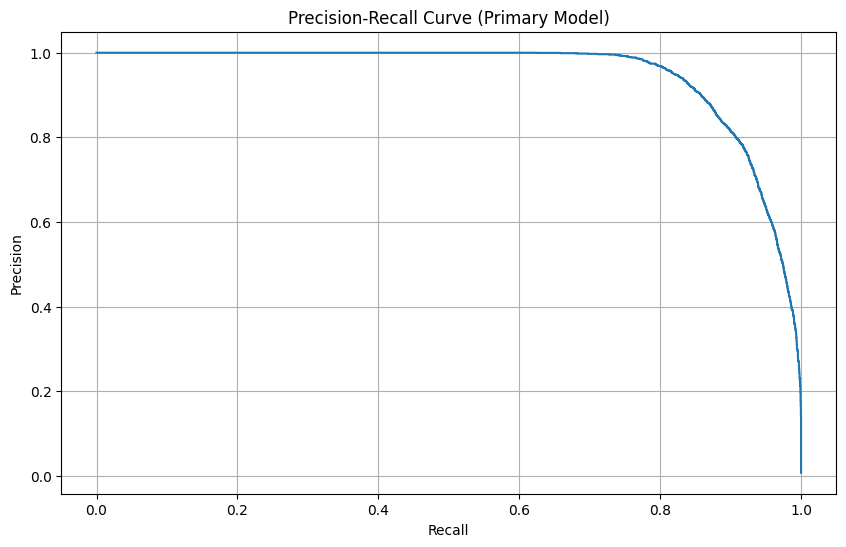

Threshold=0.1: Precision=0.1788, Recall=0.9993
Threshold=0.3: Precision=0.3701, Recall=0.9901
Threshold=0.5: Precision=0.5858, Recall=0.9608
Threshold=0.7: Precision=0.8194, Recall=0.8981
Threshold=0.9: Precision=0.9890, Recall=0.7593


In [20]:
best_model = rf_restricted_v2
pred_proba = best_model.predict_proba(X_test_restricted_v2)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Primary Model)')
plt.grid(True)
plt.show()

for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pred_at_t = (pred_proba >= t).astype(int)
    p = precision_score(y_test, pred_at_t, zero_division=0)
    r = recall_score(y_test, pred_at_t, zero_division=0)
    print(f"Threshold={t}: Precision={p:.4f}, Recall={r:.4f}")

### Choosing an Operating Threshold

| Threshold | Precision | Recall |
|---|---|---|
| 0.1 | 17.9% | 99.9% |
| 0.3 | 37.0% | 99.0% |
| 0.5 | 58.6% | 96.1% |
| 0.7 | 81.9% | 89.8% |
| 0.9 | 98.9% | 75.9% |

For a mobile money platform, where a missed fraud case can mean direct financial loss, while a false alarm typically costs only a manual review, a lower threshold (0.1–0.3) is likely the more sensible business choice prioritizing recall even at a real cost to precision. This is a business judgment call, not something a single metric can settle alone.

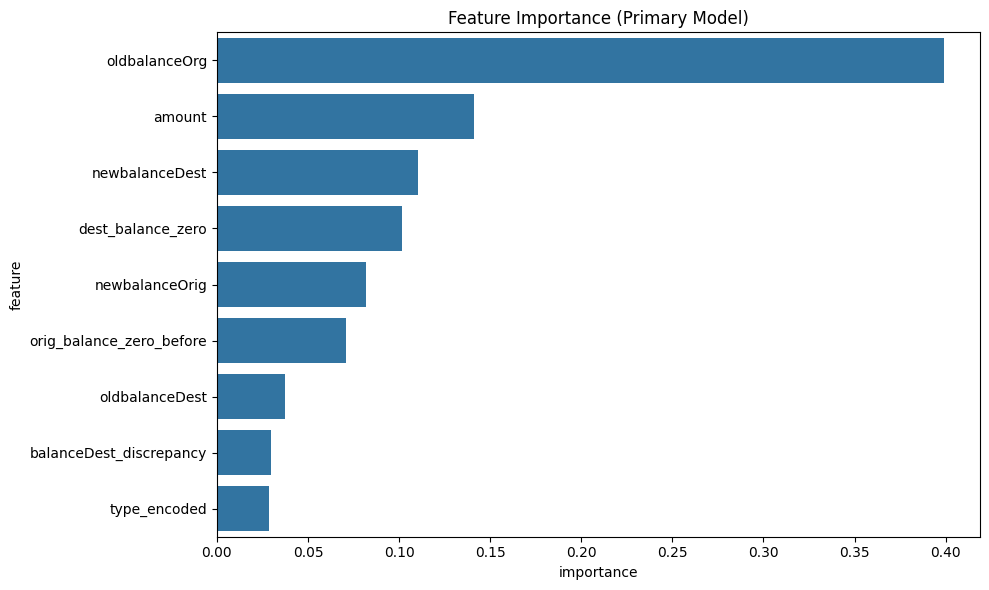

                    feature  importance
2             oldbalanceOrg    0.398915
1                    amount    0.140974
5            newbalanceDest    0.110207
7         dest_balance_zero    0.101643
3            newbalanceOrig    0.081841
8  orig_balance_zero_before    0.070860
4            oldbalanceDest    0.037311
6   balanceDest_discrepancy    0.029523
0              type_encoded    0.028726


In [21]:
feature_importance_primary = pd.DataFrame({
    'feature': features_restricted_v2,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_primary, x='importance', y='feature')
plt.title('Feature Importance (Primary Model)')
plt.tight_layout()
plt.show()

print(feature_importance_primary)

`oldbalanceOrg` is the strongest predictor (40%), followed by `amount` (14%) and `newbalanceDest` (11%). `dest_balance_zero` the "money sent to an empty account" signal from EDA contributes meaningfully (10%), confirming destination-account behavior remains a genuine, useful signal even without the dominant balance-draining pattern.

## Anomaly Detection: A Complementary Approach

Supervised models can only learn to recognize fraud patterns resembling historical examples. Isolation Forest, an unsupervised method, learns what "normal" looks like and flags deviations, without relying on fraud labels at all potentially useful for catching novel fraud patterns not present in training data.

In [22]:
iso_features = features_restricted_v2
X_train_iso = train[iso_features]
X_test_iso = test[iso_features]

iso_forest = IsolationForest(n_estimators=100, contamination=0.008, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_iso)

iso_pred = iso_forest.predict(X_test_iso)
iso_pred_binary = (iso_pred == -1).astype(int)

print(f"Precision: {precision_score(y_test, iso_pred_binary, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, iso_pred_binary, zero_division=0):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, iso_pred_binary)}")

Precision: 0.3305
Recall: 0.2475
Confusion Matrix:
[[546111   2135]
 [  3204   1054]]


In [23]:
rf_pred = (best_model.predict_proba(X_test_restricted_v2)[:, 1] >= 0.5).astype(int)

test_results = test.copy()
test_results['actual_fraud'] = y_test.values
test_results['rf_pred'] = rf_pred
test_results['iso_pred'] = iso_pred_binary

rf_missed = test_results[(test_results['actual_fraud']==1) & (test_results['rf_pred']==0)]
caught_by_iso = rf_missed[rf_missed['iso_pred']==1]

print("Fraud cases missed by Random Forest:", len(rf_missed))
print("Of those, caught by Isolation Forest:", len(caught_by_iso))

Fraud cases missed by Random Forest: 167
Of those, caught by Isolation Forest: 5


Isolation Forest performs much weaker standalone (24.8% recall vs. 96.1% for the supervised model) expected, since it has no information about known fraud patterns. However, of the 167 fraud cases the supervised model missed, Isolation Forest independently caught 5 (about 3%) a modest but genuine overlap, suggesting some fraud cases have an unusual "shape" detectable through deviation from normal behavior alone. This supports using anomaly detection as a lightweight secondary layer, not a replacement for supervised detection. The overlap is small, and this synthetic dataset likely doesn't fully represent the kind of genuinely novel fraud patterns where anomaly detection would provide its biggest real-world value.

## Conclusion

I built built a fraud detection model for mobile money transactions, focusing on `TRANSFER` and `CASH_OUT` the only transaction types where fraud occurs. The primary model (Random Forest, restricted feature set) achieves 96.1% recall and 58.6% precision (PR-AUC: 0.950), a large improvement over the platform's existing rule-based system, which catches only 0.19% of fraud.

**Key findings:**
- Fraud is confined entirely to `TRANSFER` and `CASH_OUT` transactions
- A single engineered feature (`drains_balance`) nearly perfectly separates fraud from legitimate transactions but this was investigated rather than accepted at face value, revealing a second feature silently carrying the same information even after removing the first
- After correcting for this leakage, a more realistic model still achieves strong performance (96.1% recall), driven by destination-account behavior and raw transaction values
- An unsupervised Isolation Forest model caught a small number of fraud cases the supervised model missed, supporting (modestly) its use as a complementary detection layer

**Limitations & Future Work:**
- Synthetic data; real fraud patterns are likely messier and more adversarial
- Uneven transaction volume across the simulation period is a data generation artifact worth noting
- Future work: SMOTE-based resampling, explicit cost-sensitive learning, testing against genuinely novel fraud patterns

## Example Prediction

To demonstrate the model in action, two sample transactions: one resembling a legitimate transfer, and one resembling a suspicious one based on the patterns identified in this analysis (money sent to an empty destination account).

In [24]:
# Example 1: a fairly typical, legitimate-looking transaction
legit_example = pd.DataFrame({
    'type_encoded': [1],           # TRANSFER
    'amount': [5000.0],
    'oldbalanceOrg': [15000.0],
    'newbalanceOrig': [10000.0],
    'oldbalanceDest': [8000.0],
    'newbalanceDest': [13000.0],
    'balanceDest_discrepancy': [0.0],
    'dest_balance_zero': [0],
    'orig_balance_zero_before': [0]
})

# Example 2: a suspicious transaction - large amount sent to an account with zero balance before and after
suspicious_example = pd.DataFrame({
    'type_encoded': [1],           # TRANSFER
    'amount': [250000.0],
    'oldbalanceOrg': [250000.0],
    'newbalanceOrig': [0.0],
    'oldbalanceDest': [0.0],
    'newbalanceDest': [0.0],
    'balanceDest_discrepancy': [250000.0],
    'dest_balance_zero': [1],
    'orig_balance_zero_before': [0]
})

for label, example in [("Legitimate-looking transaction", legit_example),
                         ("Suspicious transaction", suspicious_example)]:
    fraud_probability = best_model.predict_proba(example)[0][1]
    prediction = "FRAUD" if fraud_probability >= 0.5 else "NOT FRAUD"
    print(f"{label}:")
    print(f"  Predicted: {prediction} (fraud probability: {fraud_probability:.2%})\n")

Legitimate-looking transaction:
  Predicted: NOT FRAUD (fraud probability: 0.00%)

Suspicious transaction:
  Predicted: FRAUD (fraud probability: 100.00%)



In [25]:
!pip install xgboost --quiet

In [26]:
from xgboost import XGBClassifier

# scale_pos_weight = ratio of negative to positive class, a standard way to handle imbalance in XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

results.append(evaluate_model("XGBoost (truly restricted features)", xgb_model,
                                X_train_restricted_v2, X_test_restricted_v2, y_train, y_test))

scale_pos_weight: 559.7850821744627
XGBoost (truly restricted features)
  Precision: 0.7520, Recall: 0.9805, F1: 0.8512
  ROC-AUC: 0.9997, PR-AUC: 0.9691
  Confusion Matrix:
[[546869   1377]
 [    83   4175]]



### Adding XGBoost

XGBoost was added as a comparison, given it's one of the most widely used algorithms for imbalanced classification problems like fraud detection, using `scale_pos_weight` to handle the severe class imbalance (a ratio of ~560:1). It outperforms Random Forest across every metric recall improves from 96.1% to 98.1%, and precision improves substantially from 58.6% to 75.2% (PR-AUC: 0.969 vs 0.950). XGBoost is adopted as the final primary model going forward.